# Calculate the metrics from the csv

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from evaluation_utils import bootstrap_from_csv
import pickle
from pathlib import Path

In [2]:
# --- Define models and their respective CSV paths ---
# --- Define models and their respective CSV paths ---
models_to_test = {
    "DINOv2 (Video)":   "csvs/dinov2_closed/closed_dist_matrix.csv",
    "DINOv2 (Image)":   "csvs/dinov2_closed_image/closed_dist_matrix.csv",
    "DINOv2 (Img2Img)": "csvs/dinov2_closed_img2img/img2img_closed_dist_matrix.csv",
    "SwinV2 (Video)":   "csvs/swin_closed/closed_dist_matrix.csv",
    "SwinV2 (Image)":   "csvs/swin_closed_image/closed_dist_matrix.csv",
    "SwinV2 (Img2Img)": "csvs/swin_closed_img2img/img2img_closed_dist_matrix.csv",
    "ViT (Video)":      "csvs/vit_closed/closed_dist_matrix.csv",
    "ViT (Image)":      "csvs/vit_closed_image/closed_dist_matrix.csv",
    "ViT (Img2Img)":    "csvs/vit_closed_img2img/img2img_closed_dist_matrix.csv"
}

all_results = {}

# --- Run bootstrap for each ---
for name, path in models_to_test.items():
    print(f"\n{'='*30}\nProcessing {name}\n{'='*30}")
    all_results[name] = bootstrap_from_csv(path, m=100, mode="closed")


Processing DINOv2 (Video)


-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:01<00:00, 55.21it/s]



Processing DINOv2 (Image)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:01<00:00, 54.36it/s]


...

100%|██████████| 100/100 [00:01<00:00, 53.81it/s]



Processing ViT (Image)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:01<00:00, 54.91it/s]



Processing ViT (Img2Img)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:01<00:00, 54.87it/s]


In [3]:

# --- Save Configuration ---
SAVE_DIR = Path("results_data")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Define a filename for results
FILENAME = f"closed_world_benchmarks.pkl"
SAVE_PATH = SAVE_DIR / FILENAME

print(f"\n-> Saving all results to {SAVE_PATH}...")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(all_results, f)

print("✅ Results saved successfully.")


-> Saving all results to results_data/closed_world_benchmarks.pkl...
✅ Results saved successfully.


In [4]:
# Load the saved data
LOAD_PATH = "results_data/closed_world_benchmarks.pkl"

with open(LOAD_PATH, 'rb') as f:
    all_results = pickle.load(f)

print(f"Loaded results for: {list(all_results.keys())}")


Loaded results for: ['DINOv2 (Video)', 'DINOv2 (Image)', 'DINOv2 (Img2Img)', 'SwinV2 (Video)', 'SwinV2 (Image)', 'SwinV2 (Img2Img)', 'ViT (Video)', 'ViT (Image)', 'ViT (Img2Img)']


In [5]:
# --- Print results ---
print("\n" + "="*115)
print(f"{'Model':<25} | {'mAP [95% CI]':<28} | {'Rank-1 [95% CI]':<28} | {'Rank-5 [95% CI]':<28}")
print("="*115)

for name, res in all_results.items():
    # mAP
    m_full = res['full_set']['mAP']
    m_low, m_high = res.get('mAP_ci', (m_full, m_full))
    map_str = f"{m_full:.3f} [{m_low:.3f}-{m_high:.3f}]"
    
    #  Rank-1 
    r1_full = res['full_set']['cmc'][0]
    r1_l = res.get('cmc_ci_lower', [r1_full])[0]
    r1_u = res.get('cmc_ci_upper', [r1_full])[0]
    r1_str = f"{r1_full:.3f} [{r1_l:.3f}-{r1_u:.3f}]"
    
    # Rank-5 
    idx = 4 if len(res['full_set']['cmc']) >= 5 else -1
    r5_full = res['full_set']['cmc'][idx]
    r5_l = res.get('cmc_ci_lower', [r5_full])[idx]
    r5_u = res.get('cmc_ci_upper', [r5_full])[idx]
    r5_str = f"{r5_full:.3f} [{r5_l:.3f}-{r5_u:.3f}]"
    
    print(f"{name:<25} | {map_str:<28} | {r1_str:<28} | {r5_str:<28}")

print("-" * 115)


Model                     | mAP [95% CI]                 | Rank-1 [95% CI]              | Rank-5 [95% CI]             
DINOv2 (Video)            | 0.543 [0.522-0.569]          | 0.583 [0.555-0.609]          | 0.782 [0.754-0.807]         
DINOv2 (Image)            | 0.443 [0.421-0.462]          | 0.448 [0.419-0.470]          | 0.666 [0.642-0.692]         
DINOv2 (Img2Img)          | 0.356 [0.338-0.373]          | 0.376 [0.353-0.400]          | 0.608 [0.583-0.634]         
SwinV2 (Video)            | 0.285 [0.263-0.303]          | 0.271 [0.238-0.292]          | 0.519 [0.490-0.547]         
SwinV2 (Image)            | 0.214 [0.199-0.228]          | 0.201 [0.182-0.219]          | 0.389 [0.358-0.409]         
SwinV2 (Img2Img)          | 0.166 [0.152-0.178]          | 0.153 [0.138-0.169]          | 0.336 [0.316-0.354]         
ViT (Video)               | 0.309 [0.286-0.326]          | 0.316 [0.288-0.336]          | 0.542 [0.511-0.569]         
ViT (Image)               | 0.225 [0.209-0.240]

/tmp/ipykernel_1100605/27127669.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(all_results))


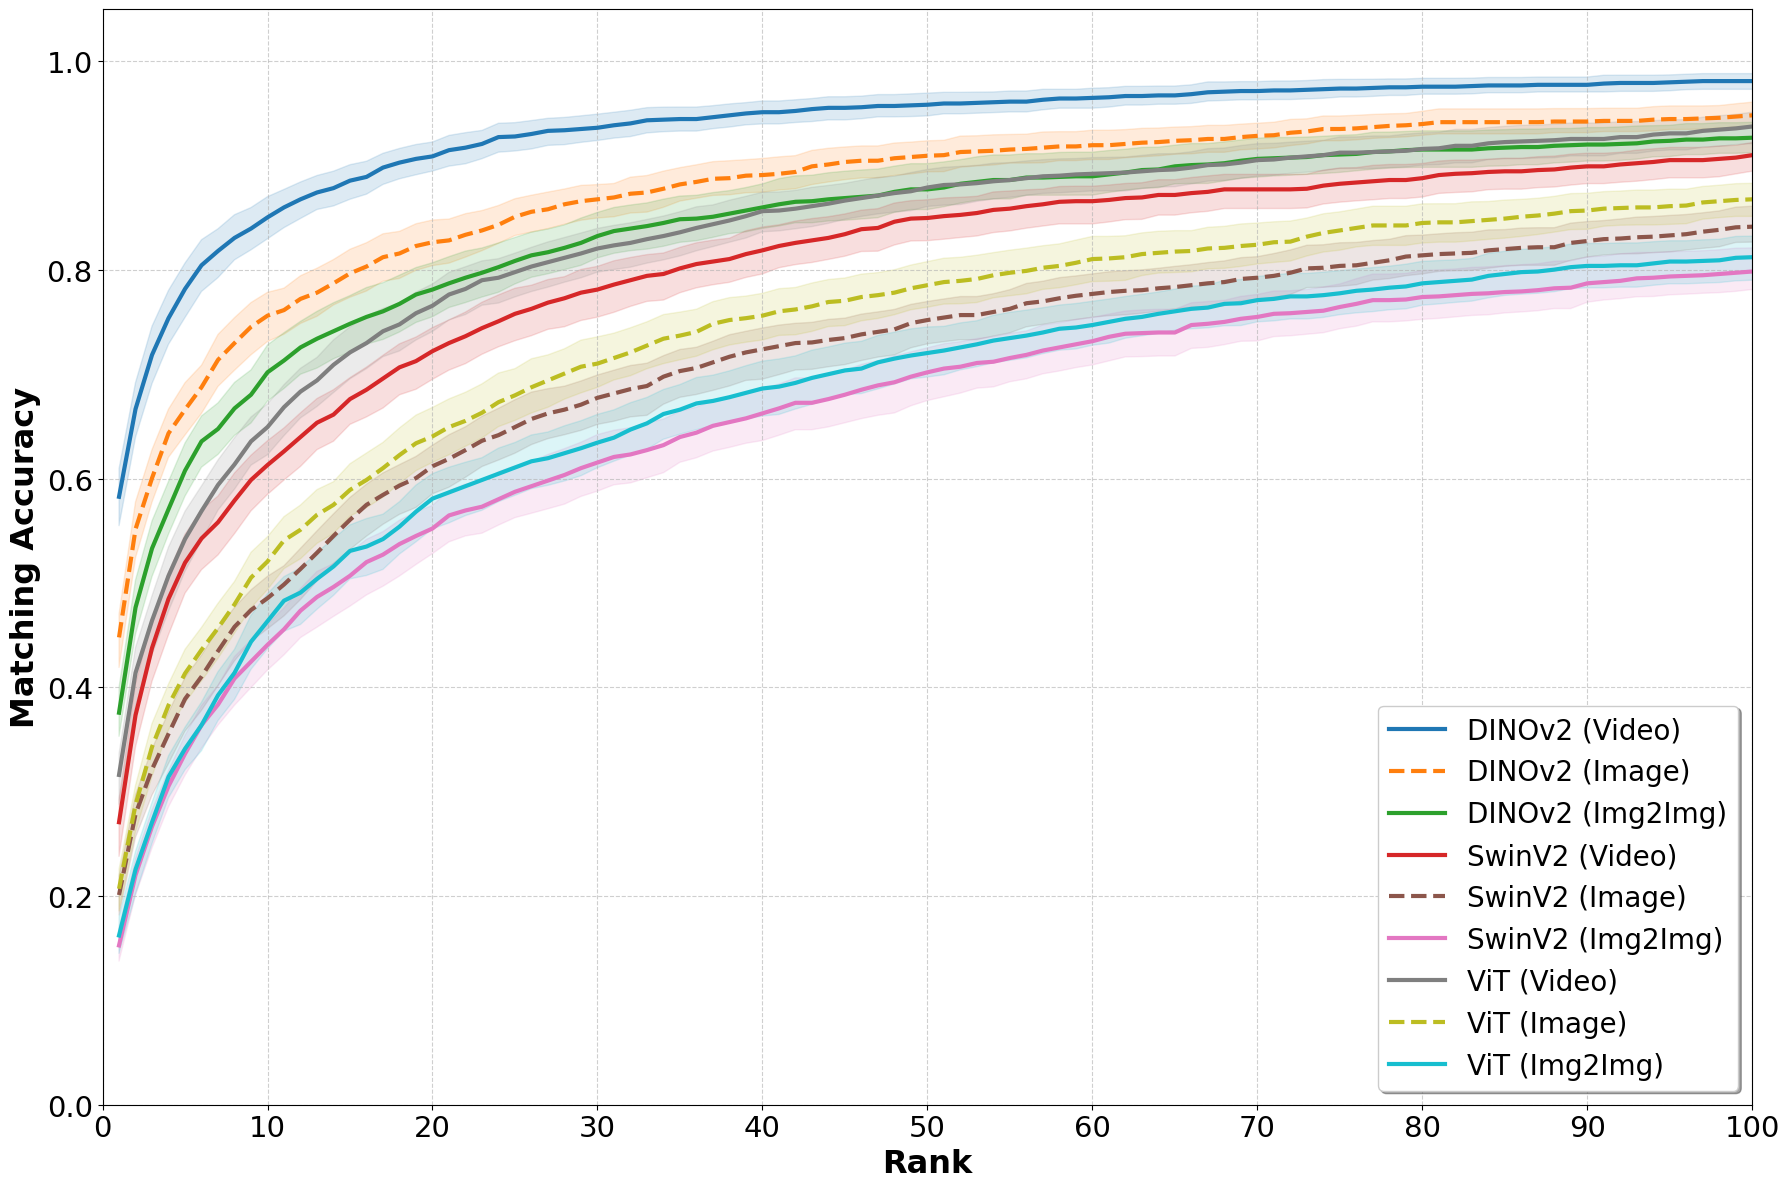

In [6]:
# -------------------------------------------------------------
# --- Plotting Configuration ---
# ------------------------------------------------------------- 
MAX_RANK = 100      
TICK_STEP = 10    
FONT_SIZE = 21       

# -------------------------------------------------------------
# --- Plotting CMC Curves with Confidence Intervals ---
# -------------------------------------------------------------

plt.figure(figsize=(18, 12))
colors = plt.cm.get_cmap('tab10', len(all_results))

for i, (name, res) in enumerate(all_results.items()):
    # Using the ranks from the full set result
    ranks = np.arange(1, len(res["full_set"]["cmc"]) + 1)
    
    # Primary line: Full Set result
    cmc_full = res["full_set"]["cmc"]
    
    # Uncertainty: Bootstrap lower and upper bounds
    cmc_lower = res["cmc_ci_lower"]
    cmc_upper = res["cmc_ci_upper"]
    
    color = colors(i)
    
    # Plot the Shaded Uncertainty Interval (95% CI)
    plt.fill_between(ranks, cmc_lower, cmc_upper, color=color, alpha=0.15)
    
    # Plot the Full Set Line
    line_style = '-' if "(Video)" in name or "(Image)" not in name else '--'
    plt.plot(ranks, cmc_full, color=color, linestyle=line_style, linewidth=3, 
             label=f"{name}")

# --- Format the Plot with Larger Fonts ---
plt.xlabel("Rank", fontsize=FONT_SIZE + 2, fontweight='bold')
plt.ylabel("Matching Accuracy", fontsize=FONT_SIZE + 2, fontweight='bold')

# --- Axis Tick Labels ---
plt.xticks(np.arange(0, MAX_RANK + 1, step=TICK_STEP), fontsize=FONT_SIZE)
plt.yticks(np.arange(0, 1.05, step=0.2), fontsize=FONT_SIZE)

# --- Dynamic Axis Control ---
plt.xlim(0, MAX_RANK) 
plt.ylim(0, 1.05)

plt.grid(True, linestyle='--', alpha=0.6)

# --- Legend Configuration ---
# Placed in lower right as CMC curves typically trend upward
plt.legend(fontsize=FONT_SIZE - 1, loc='lower right', frameon=True, shadow=True, facecolor='white')

plt.tight_layout()
plt.savefig("figs/closed_world.png")
plt.show()

# Testing background leakage

In [3]:
import numpy as np

# --- Define models and their respective CSV paths ---
models_to_test = {
    # Original Video Tracks
    "DINOv2": "csvs/dinov2_closed/closed_dist_matrix.csv",
    "DINOv2 (Masked)": "csvs/dinov2_closed_masked/masked_dog_closed_dist_matrix.csv",
    
    # Image-to-Video Tracks & Baselines
    "DINOv2 (Image)": "csvs/dinov2_closed_image/closed_dist_matrix.csv",
    "DINOv2 (Image, GT Query)": "csvs/dinov2_closed_image_gtq/gtq_image_closed_dist_matrix.csv",
    "DINOv2 (Image, Masked)": "csvs/dinov2_closed_image_masked/masked_image_closed_dist_matrix.csv",
    "DINOv2 (Image, Masked - GT Query)": "csvs/dinov2_closed_image_masked_gtq/masked_gtq_image_closed_dist_matrix.csv",

    # Image-to-Image Tracks & Baselines
    "DINOv2 (Img2Img)": "csvs/dinov2_closed_img2img/img2img_closed_dist_matrix.csv",
    "DINOv2 (Img2Img, GT Both)": "csvs/dinov2_closed_attention_finetune_False_img2img_gtboth/gtboth_img2img_closed_dist_matrix.csv",
    "DINOv2 (Img2Img, Masked)": "csvs/dinov2_closed_attention_finetune_False_img2img_masked/masked_img2img_closed_dist_matrix.csv",
    "DINOv2 (Img2Img, Masked - GT Both)": "csvs/dinov2_closed_attention_finetune_False_img2img_masked_gtboth/masked_gtboth_img2img_closed_dist_matrix.csv"
}

all_results = {}

# --- Run bootstrap for each ---
for name, path in models_to_test.items():
    print(f"\n{'='*30}\nProcessing {name}\n{'='*30}")
    try:
        all_results[name] = bootstrap_from_csv(path, m=100, mode="closed")
    except FileNotFoundError:
        print(f"File not found for {name}: {path}. Skipping...")

# --- Print results ---
print("\n" + "="*130)
print(f"{'Model':<40} | {'mAP [95% CI]':<28} | {'Rank-1 [95% CI]':<28} | {'Rank-5 [95% CI]':<28}")
print("="*130)

for name, res in all_results.items():
    # mAP
    m_full = res['full_set']['mAP']
    m_low, m_high = res.get('mAP_ci', (m_full, m_full))
    map_str = f"{m_full:.3f} [{m_low:.3f}-{m_high:.3f}]"
    
    # Rank-1 
    r1_full = res['full_set']['cmc'][0]
    r1_l = res.get('cmc_ci_lower', [r1_full])[0]
    r1_u = res.get('cmc_ci_upper', [r1_full])[0]
    r1_str = f"{r1_full:.3f} [{r1_l:.3f}-{r1_u:.3f}]"
    
    # Rank-5 
    idx = 4 if len(res['full_set']['cmc']) >= 5 else -1
    r5_full = res['full_set']['cmc'][idx]
    r5_l = res.get('cmc_ci_lower', [r5_full])[idx]
    r5_u = res.get('cmc_ci_upper', [r5_full])[idx]
    r5_str = f"{r5_full:.3f} [{r5_l:.3f}-{r5_u:.3f}]"
    
    print(f"{name:<40} | {map_str:<28} | {r1_str:<28} | {r5_str:<28}")

print("-" * 130)


Processing DINOv2


-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:01<00:00, 55.55it/s]



Processing DINOv2 (Masked)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:01<00:00, 54.96it/s]


...


Processing DINOv2 (Img2Img, Masked)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:01<00:00, 56.51it/s]



Processing DINOv2 (Img2Img, Masked - GT Both)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:01<00:00, 55.82it/s]


Model                                    | mAP [95% CI]                 | Rank-1 [95% CI]              | Rank-5 [95% CI]             
DINOv2                                   | 0.543 [0.522-0.569]          | 0.583 [0.555-0.609]          | 0.782 [0.754-0.807]         
DINOv2 (Masked)                          | 0.207 [0.189-0.226]          | 0.221 [0.199-0.250]          | 0.380 [0.355-0.410]         
DINOv2 (Image)                           | 0.443 [0.421-0.462]          | 0.448 [0.419-0.470]          | 0.666 [0.642-0.692]         
DINOv2 (Image, GT Query)                 | 0.460 [0.435-0.481]          | 0.466 [0.434-0.491]          | 0.686 [0.656-0.710]         
DINOv2 (Image, Masked)                   | 0.071 [0.060-0.081]          | 0.075 [0.062-0.088]          | 0.128 [0.113-0.146]         
DINOv2 (Image, Masked - GT Query)        | 0.009 [0.007-0.011]          | 0.004 [0.001-0.007]          | 0.016 [0.009-0.021]         
DINOv2 (Img2Img)                         | 0.356 [0.338-0.373

# New models and weigts results

In [14]:
# --- Define models and their respective CSV paths ---
models_to_test = {
    # --- DINOv2 ---
    "DINOv2 (Video)":   "csvs/dinov2_closed/closed_dist_matrix.csv",
    "DINOv2 (Image)":   "csvs/dinov2_closed_image/closed_dist_matrix.csv",
    "DINOv2 (Image-to-Image)": "csvs/dinov2_closed_img2img/img2img_closed_dist_matrix.csv", 

    # --- ConvNeXt ---
    "ConvNeXt (Video)":          "csvs/convnetxt_closed_vid2vid/vid2vid_closed_dist_matrix.csv",
    "ConvNeXt (Image-to-Video)": "csvs/convnetxt_closed_img2vid/img2vid_closed_dist_matrix.csv",
    "ConvNeXt (Image-to-Image)": "csvs/convnetxt_closed_attention_finetune_False_img2img/img2img_closed_dist_matrix.csv",

    # --- ViT ---
    "ViT (Video)":      "csvs/vit_closed/closed_dist_matrix.csv",
    "ViT (Image)":      "csvs/vit_closed_image/closed_dist_matrix.csv",
    "ViT (Img2Img)":    "csvs/vit_closed_img2img/img2img_closed_dist_matrix.csv",
    
    
    "ViT New Weights (Video)":          "csvs/vit_closed_attention_finetune_False_vid2vid/vid2vid_closed_dist_matrix.csv",
    "ViT New Weights (Image-to-Video)": "csvs/vit_closed_attention_finetune_False_img2vid/img2vid_closed_dist_matrix.csv",
    "ViT New Weights (Image-to-Image)": "csvs/vit_closed_attention_finetune_False_img2img/img2img_closed_dist_matrix.csv",

    # --- SwinV2 ---
    "SwinV2 (Video)":   "csvs/swin_closed/closed_dist_matrix.csv",
    "SwinV2 (Image)":   "csvs/swin_closed_image/closed_dist_matrix.csv",
    "SwinV2 (Img2Img)": "csvs/swin_closed_img2img/img2img_closed_dist_matrix.csv",
    
    "SwinV2 New Weights (Video)":          "csvs/swin_closed_attention_finetune_False_vid2vid/vid2vid_closed_dist_matrix.csv",
    "SwinV2 New Weights (Image-to-Video)": "csvs/swin_closed_attention_finetune_False_img2vid/img2vid_closed_dist_matrix.csv",
    "SwinV2 New Weights (Image-to-Image)": "csvs/swin_closed_attention_finetune_False_img2img/img2img_closed_dist_matrix.csv",
}

all_results = {}

# --- Run bootstrap for each ---
for name, path in models_to_test.items():
    print(f"\n{'='*30}\nProcessing {name}\n{'='*30}")
    # Try/except block ensures the script keeps running if any new img2img files are missing
    try:
        all_results[name] = bootstrap_from_csv(path, m=100, mode="closed")
    except FileNotFoundError:
        print(f"File not found for {name}: {path}. Skipping...")

# --- Print Summary Table ---
print(f"\n{'Model Name':<42} | {'mAP (95% CI)':<25} | {'Rank-1 (95% CI)':<25} | {'Rank-5 (95% CI)':<25}")
print("=" * 125)

for name, res in all_results.items():
    # mAP
    m_full = res['full_set']['mAP']
    m_low, m_high = res.get('mAP_ci', (m_full, m_full))
    map_str = f"{m_full:.3f} [{m_low:.3f}-{m_high:.3f}]"
    
    # Rank-1 
    r1_full = res['full_set']['cmc'][0]
    r1_l = res.get('cmc_ci_lower', [r1_full])[0]
    r1_u = res.get('cmc_ci_upper', [r1_full])[0]
    r1_str = f"{r1_full:.3f} [{r1_l:.3f}-{r1_u:.3f}]"
    
    # Rank-5 
    idx = 4 if len(res['full_set']['cmc']) >= 5 else -1
    r5_full = res['full_set']['cmc'][idx]
    r5_l = res.get('cmc_ci_lower', [r5_full])[idx]
    r5_u = res.get('cmc_ci_upper', [r5_full])[idx]
    r5_str = f"{r5_full:.3f} [{r5_l:.3f}-{r5_u:.3f}]"
    
    print(f"{name:<42} | {map_str:<25} | {r1_str:<25} | {r5_str:<25}")

print("-" * 125)


Processing DINOv2 (Video)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:03<00:00, 29.86it/s]



Processing DINOv2 (Image)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:02<00:00, 34.55it/s]


...


Processing SwinV2 New Weights (Image-to-Video)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:02<00:00, 34.73it/s]



Processing SwinV2 New Weights (Image-to-Image)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:02<00:00, 34.69it/s]


Model Name                                 | mAP (95% CI)              | Rank-1 (95% CI)           | Rank-5 (95% CI)          
DINOv2 (Video)                             | 0.543 [0.522-0.569]       | 0.583 [0.555-0.609]       | 0.782 [0.754-0.807]      
DINOv2 (Image)                             | 0.443 [0.421-0.462]       | 0.448 [0.419-0.470]       | 0.666 [0.642-0.692]      
DINOv2 (Image-to-Image)                    | 0.356 [0.338-0.373]       | 0.376 [0.353-0.400]       | 0.608 [0.583-0.634]      
ConvNeXt (Video)                           | 0.360 [0.336-0.383]       | 0.371 [0.338-0.397]       | 0.602 [0.570-0.631]      
ConvNeXt (Image-to-Video)                  | 0.281 [0.262-0.302]       | 0.271 [0.249-0.292]       | 0.494 [0.468-0.523]      
ConvNeXt (Image-to-Image)                  | 0.149 [0.135-0.164]       | 0.151 [0.133-0.171]       | 0.304 [0.279-0.327]      
ViT (Video)                                | 0.309 [0.286-0.326]       | 0.316 [0.288-0.336]       | 0.542 [0.

# Fully fine-tuned vs normal performance

In [13]:
# --- Define models and their respective CSV paths ---
models_to_test = {
    # --- Original DINOv2 Baseline ---
    "DINOv2 (Video)": "csvs/dinov2_closed/closed_dist_matrix.csv", 
    "DINOv2 (Image-to-Video)": "csvs/dinov2_closed_image/closed_dist_matrix.csv",
    "DINOv2 (Img2Img)": "csvs/dinov2_closed_img2img/img2img_closed_dist_matrix.csv",
    
    # --- Fully Fine-Tuned DINOv2 ---
    "DINOv2 Fine-Tuned (Video)": "csvs/dinov2_closed_attention_finetune_True_vid2vid/vid2vid_closed_dist_matrix.csv", 
    "DINOv2 Fine-Tuned (Image-to-Video)": "csvs/dinov2_closed_attention_finetune_True_img2vid/img2vid_closed_dist_matrix.csv",
    "DINOv2 Fine-Tuned (Image-to-Image)": "csvs/dinov2_closed_attention_finetune_True_img2img/img2img_closed_dist_matrix.csv",
}

all_results = {}

# --- Run bootstrap for each ---
for name, path in models_to_test.items():
    print(f"\n{'='*30}\nProcessing {name}\n{'='*30}")
    
    # Wrapping in a try-except block just in case a CSV hasn't finished generating yet
    try:
        all_results[name] = bootstrap_from_csv(path, m=100, mode="closed")
    except FileNotFoundError:
        print(f"-> Skipping {name}: CSV not found at {path}")
        continue


# --- Print results ---
print("\n" + "="*115)
print(f"{'Model':<38} | {'mAP [95% CI]':<25} | {'Rank-1 [95% CI]':<25} | {'Rank-5 [95% CI]':<25}")
print("="*115)

for name, res in all_results.items():
    # mAP
    m_full = res['full_set']['mAP']
    m_low, m_high = res.get('mAP_ci', (m_full, m_full))
    map_str = f"{m_full:.3f} [{m_low:.3f}-{m_high:.3f}]"
    
    # Rank-1 
    r1_full = res['full_set']['cmc'][0]
    r1_l = res.get('cmc_ci_lower', [r1_full])[0]
    r1_u = res.get('cmc_ci_upper', [r1_full])[0]
    r1_str = f"{r1_full:.3f} [{r1_l:.3f}-{r1_u:.3f}]"
    
    # Rank-5 
    idx = 4 if len(res['full_set']['cmc']) >= 5 else -1
    r5_full = res['full_set']['cmc'][idx]
    r5_l = res.get('cmc_ci_lower', [r5_full])[idx]
    r5_u = res.get('cmc_ci_upper', [r5_full])[idx]
    r5_str = f"{r5_full:.3f} [{r5_l:.3f}-{r5_u:.3f}]"
    
    print(f"{name:<38} | {map_str:<25} | {r1_str:<25} | {r5_str:<25}")

print("-" * 115)


Processing DINOv2 (Video)


-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:01<00:00, 56.42it/s]



Processing DINOv2 (Image-to-Video)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:01<00:00, 55.77it/s]


...


Processing DINOv2 Fine-Tuned (Image-to-Video)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:01<00:00, 56.23it/s]



Processing DINOv2 Fine-Tuned (Image-to-Image)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:01<00:00, 56.07it/s]


Model                                  | mAP [95% CI]              | Rank-1 [95% CI]           | Rank-5 [95% CI]          
DINOv2 (Video)                         | 0.543 [0.522-0.569]       | 0.583 [0.555-0.609]       | 0.782 [0.754-0.807]      
DINOv2 (Image-to-Video)                | 0.443 [0.421-0.462]       | 0.448 [0.419-0.470]       | 0.666 [0.642-0.692]      
DINOv2 (Img2Img)                       | 0.356 [0.338-0.373]       | 0.376 [0.353-0.400]       | 0.608 [0.583-0.634]      
DINOv2 Fine-Tuned (Video)              | 0.458 [0.438-0.482]       | 0.494 [0.470-0.519]       | 0.710 [0.684-0.734]      
DINOv2 Fine-Tuned (Image-to-Video)     | 0.386 [0.366-0.409]       | 0.389 [0.367-0.417]       | 0.627 [0.601-0.652]      
DINOv2 Fine-Tuned (Image-to-Image)     | 0.270 [0.250-0.286]       | 0.275 [0.252-0.296]       | 0.496 [0.465-0.519]      
-------------------------------------------------------------------------------------------------------------------


# Adding identity loss

In [14]:
# --- Define models and their respective CSV paths ---
# Comparing Baseline DINOv2 vs. DINOv2 trained with Identity Loss
models_to_test = {
    # --- Standard DINOv2 (Triplet Loss Only) ---
        "DINOv2 (Video)": "csvs/dinov2_closed/closed_dist_matrix.csv", 
    "DINOv2 (Image-to-Video)": "csvs/dinov2_closed_image/closed_dist_matrix.csv",
    
    # --- DINOv2 with Identity / Cross-Entropy Loss ---
    # Update the folder tag (e.g., '_idloss' or '_cls') if your run_name differs
    "DINOv2 + ID Loss (Video)":  "csvs/dinov2_closed_attention_finetune_False_vid2vid/vid2vid_closed_dist_matrix.csv", 

}

all_results = {}

# --- Run bootstrap for each ---
for name, path in models_to_test.items():
    print(f"\n{'='*30}\nProcessing {name}\n{'='*30}")
    
    # Wrapping in a try-except block in case a job is still running
    try:
        # Set m=100 for your final statistical comparison
        all_results[name] = bootstrap_from_csv(path, m=100, mode="closed")
    except FileNotFoundError:
        print(f"-> Skipping {name}: CSV not found at {path}")
        continue


# --- Print results ---
print("\n" + "="*115)
print(f"{'Model Experiment':<34} | {'mAP [95% CI]':<26} | {'Rank-1 [95% CI]':<26} | {'Rank-5 [95% CI]':<26}")
print("="*115)

for name, res in all_results.items():
    # mAP
    m_full = res['full_set']['mAP']
    m_low, m_high = res.get('mAP_ci', (m_full, m_full))
    map_str = f"{m_full:.3f} [{m_low:.3f}-{m_high:.3f}]"
    
    # Rank-1 
    r1_full = res['full_set']['cmc'][0]
    r1_l = res.get('cmc_ci_lower', [r1_full])[0]
    r1_u = res.get('cmc_ci_upper', [r1_full])[0]
    r1_str = f"{r1_full:.3f} [{r1_l:.3f}-{r1_u:.3f}]"
    
    # Rank-5 
    idx = 4 if len(res['full_set']['cmc']) >= 5 else -1
    r5_full = res['full_set']['cmc'][idx]
    r5_l = res.get('cmc_ci_lower', [r5_full])[idx]
    r5_u = res.get('cmc_ci_upper', [r5_full])[idx]
    r5_str = f"{r5_full:.3f} [{r5_l:.3f}-{r5_u:.3f}]"
    
    print(f"{name:<34} | {map_str:<26} | {r1_str:<26} | {r5_str:<26}")

print("-" * 115)


Processing DINOv2 (Video)


-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:01<00:00, 56.57it/s]



Processing DINOv2 (Image-to-Video)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:01<00:00, 54.99it/s]



Processing DINOv2 + ID Loss (Video)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:01<00:00, 56.69it/s]


Model Experiment                   | mAP [95% CI]               | Rank-1 [95% CI]            | Rank-5 [95% CI]           
DINOv2 (Video)                     | 0.543 [0.522-0.569]        | 0.583 [0.555-0.609]        | 0.782 [0.754-0.807]       
DINOv2 (Image-to-Video)            | 0.443 [0.421-0.462]        | 0.448 [0.419-0.470]        | 0.666 [0.642-0.692]       
DINOv2 + ID Loss (Video)           | 0.388 [0.364-0.409]        | 0.416 [0.386-0.441]        | 0.640 [0.605-0.669]       
-------------------------------------------------------------------------------------------------------------------


# Different aggregation strategies

In [8]:
# --- Define models and their respective CSV paths ---
# Comparing different pooling strategies for FROZEN DINOv2 across all modalities
models_to_test = {
    # ---------------------------------------------------------
    # 1. Video-to-Video
    # ---------------------------------------------------------
    # Note: Using your original path for the Attention baseline, adjust if it's different!
    "Vid2Vid (Attention)": "csvs/dinov2_closed/closed_dist_matrix.csv", 
    "Vid2Vid (Mean)": "csvs/dinov2_closed_mean_finetune_False_vid2vid/vid2vid_closed_dist_matrix.csv",
    "Vid2Vid (Max)": "csvs/dinov2_closed_max_finetune_False_vid2vid/vid2vid_closed_dist_matrix.csv",

    # ---------------------------------------------------------
    # 2. Image-to-Video
    # ---------------------------------------------------------
    "Img2Vid (Attention)": "csvs/dinov2_closed_image/closed_dist_matrix.csv",
    "Img2Vid (Mean)": "csvs/dinov2_closed_mean_finetune_False_img2vid/img2vid_closed_dist_matrix.csv",
    "Img2Vid (Max)": "csvs/dinov2_closed_max_finetune_False_img2vid/img2vid_closed_dist_matrix.csv",

    # ---------------------------------------------------------
    # 3. Image-to-Image
    # ---------------------------------------------------------
    # "Img2Img (Attention)": "csvs/dinov2_closed_img2img/img2img_closed_dist_matrix.csv", 
    # "Img2Img (Mean)": "csvs/dinov2_closed_mean_finetune_False_img2img/img2img_closed_dist_matrix.csv",
    # "Img2Img (Max)": "csvs/dinov2_closed_max_finetune_False_img2img/img2img_closed_dist_matrix.csv",
}

all_results = {}

# --- Run bootstrap for each ---
for name, path in models_to_test.items():
    print(f"\n{'='*30}\nProcessing {name}\n{'='*30}")
    
    # Wrapping in a try-except block just in case a CSV hasn't finished generating yet
    try:
        # Note: Set m=100 for your final run to get stable confidence intervals!
        all_results[name] = bootstrap_from_csv(path, m=100, mode="closed")
    except FileNotFoundError:
        print(f"-> Skipping {name}: CSV not found at {path}")
        continue


# --- Print results ---
print("\n" + "="*115)
print(f"{'Modality & Aggregation':<32} | {'mAP [95% CI]':<28} | {'Rank-1 [95% CI]':<28} | {'Rank-5 [95% CI]':<28}")
print("="*115)

for name, res in all_results.items():
    # Insert a visual separator between different modalities for readability
    if "(Attention)" in name and "Vid2Vid" not in name:
        print("-" * 115)

    # mAP
    m_full = res['full_set']['mAP']
    m_low, m_high = res.get('mAP_ci', (m_full, m_full))
    map_str = f"{m_full:.3f} [{m_low:.3f}-{m_high:.3f}]"
    
    # Rank-1 
    r1_full = res['full_set']['cmc'][0]
    r1_l = res.get('cmc_ci_lower', [r1_full])[0]
    r1_u = res.get('cmc_ci_upper', [r1_full])[0]
    r1_str = f"{r1_full:.3f} [{r1_l:.3f}-{r1_u:.3f}]"
    
    # Rank-5 
    idx = 4 if len(res['full_set']['cmc']) >= 5 else -1
    r5_full = res['full_set']['cmc'][idx]
    r5_l = res.get('cmc_ci_lower', [r5_full])[idx]
    r5_u = res.get('cmc_ci_upper', [r5_full])[idx]
    r5_str = f"{r5_full:.3f} [{r5_l:.3f}-{r5_u:.3f}]"
    
    print(f"{name:<32} | {map_str:<28} | {r1_str:<28} | {r5_str:<28}")

print("-" * 115)


Processing Vid2Vid (Attention)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:01<00:00, 56.89it/s]



Processing Vid2Vid (Mean)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:01<00:00, 56.61it/s]


...


Processing Img2Vid (Mean)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:01<00:00, 57.45it/s]



Processing Img2Vid (Max)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:01<00:00, 57.37it/s]


Modality & Aggregation           | mAP [95% CI]                 | Rank-1 [95% CI]              | Rank-5 [95% CI]             
Vid2Vid (Attention)              | 0.543 [0.522-0.569]          | 0.583 [0.555-0.609]          | 0.782 [0.754-0.807]         
Vid2Vid (Mean)                   | 0.333 [0.312-0.349]          | 0.351 [0.321-0.376]          | 0.565 [0.537-0.594]         
Vid2Vid (Max)                    | 0.241 [0.221-0.258]          | 0.271 [0.240-0.299]          | 0.454 [0.425-0.486]         
-------------------------------------------------------------------------------------------------------------------
Img2Vid (Attention)              | 0.443 [0.421-0.462]          | 0.448 [0.419-0.470]          | 0.666 [0.642-0.692]         
Img2Vid (Mean)                   | 0.302 [0.278-0.321]          | 0.314 [0.287-0.338]          | 0.519 [0.491-0.545]         
Img2Vid (Max)                    | 0.199 [0.180-0.219]          | 0.199 [0.178-0.224]          | 0.400 [0.369-0.431]         
-